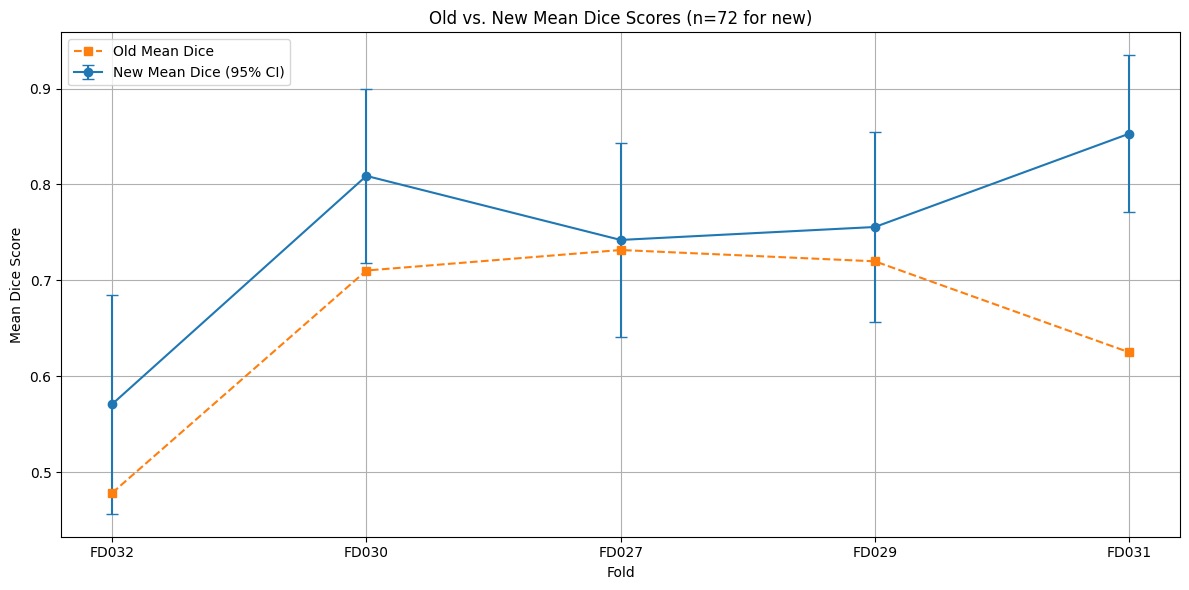

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

# 1) Your data
df = pd.DataFrame({
    'Fold':      ['FD032','FD030','FD027','FD029','FD031'],
    'OldMean':   [0.4782,  0.7102,  0.7316,  0.7198,  0.6249],
    'NewMean':   [0.5708,  0.8089,  0.7421,  0.7556,  0.8529],
})

# 2) Compute 95% CI margins for NewMean (n=72)
z = norm.ppf(0.975)
n = 72
se = np.sqrt(df['NewMean'] * (1 - df['NewMean']) / n)
df['Margin'] = z * se

# 3) Plot
x = np.arange(len(df))
plt.figure(figsize=(12, 6))

# new mean with error bars
plt.errorbar(
    x, df['NewMean'],
    yerr=df['Margin'],
    fmt='o-', capsize=4,
    label='New Mean Dice (95% CI)'
)

# old mean
plt.plot(
    x, df['OldMean'],
    's--',
    label='Old Mean Dice'
)

plt.xticks(x, df['Fold'])
plt.xlabel('Fold')
plt.ylabel('Mean Dice Score')
plt.title('Old vs. New Mean Dice Scores (n=72 for new)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
